<a href="https://colab.research.google.com/github/Bamboohoccode/LLMs_From_Scratch/blob/main/Chapter_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7.1 Introduction to instruction finetuning

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

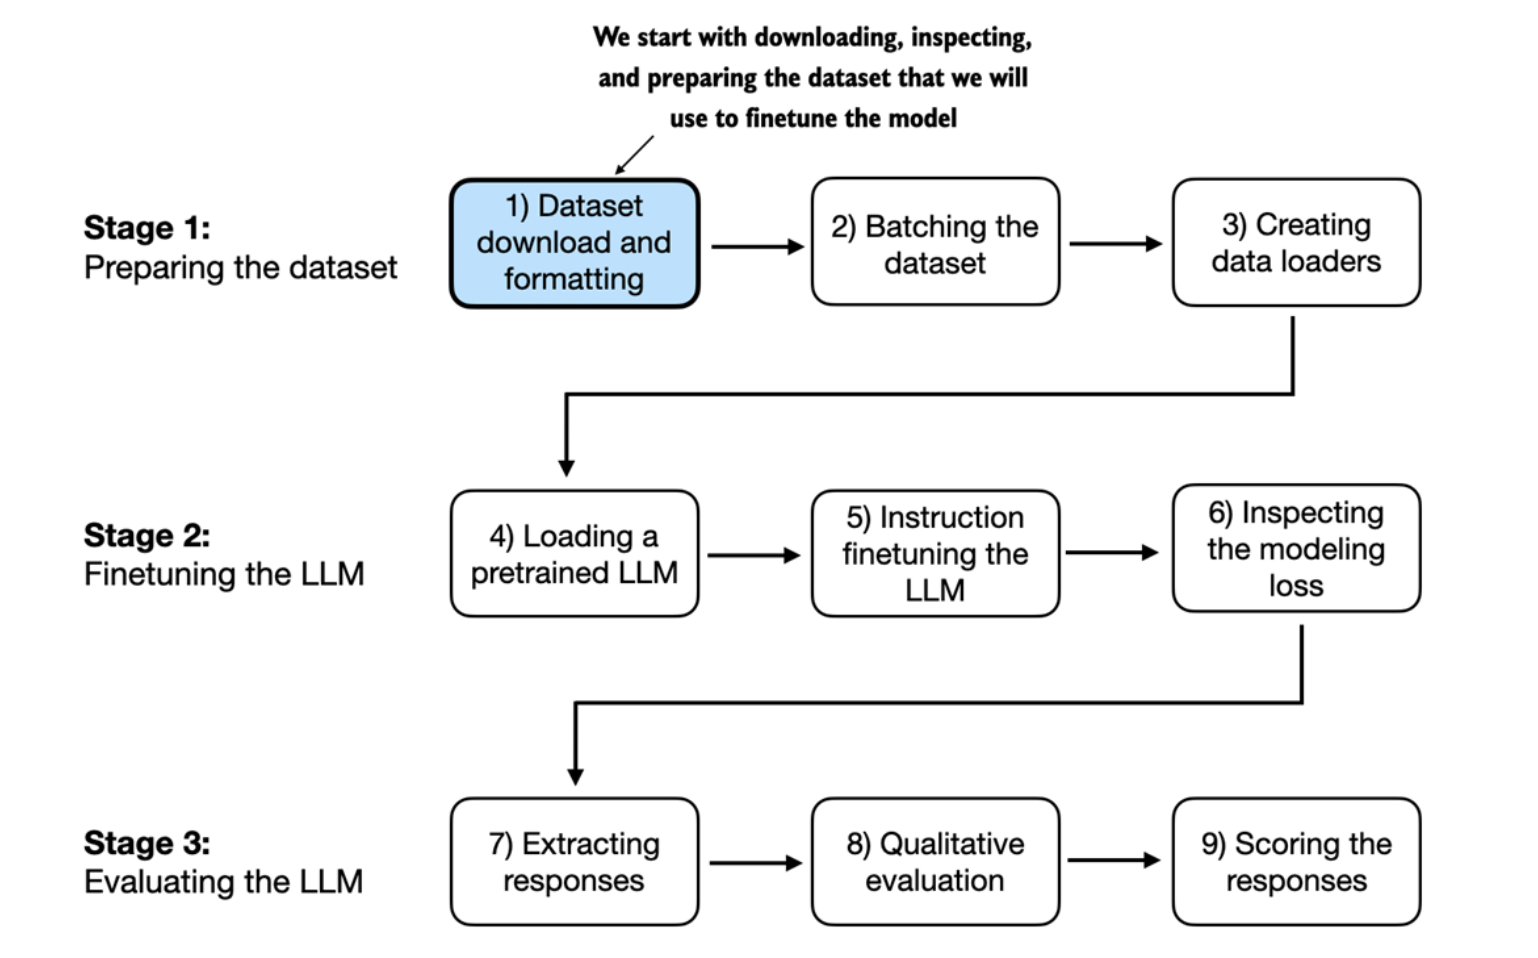

In this chapter, we focus on improving the LLM's ability to follow such instructions and
generate a desired response


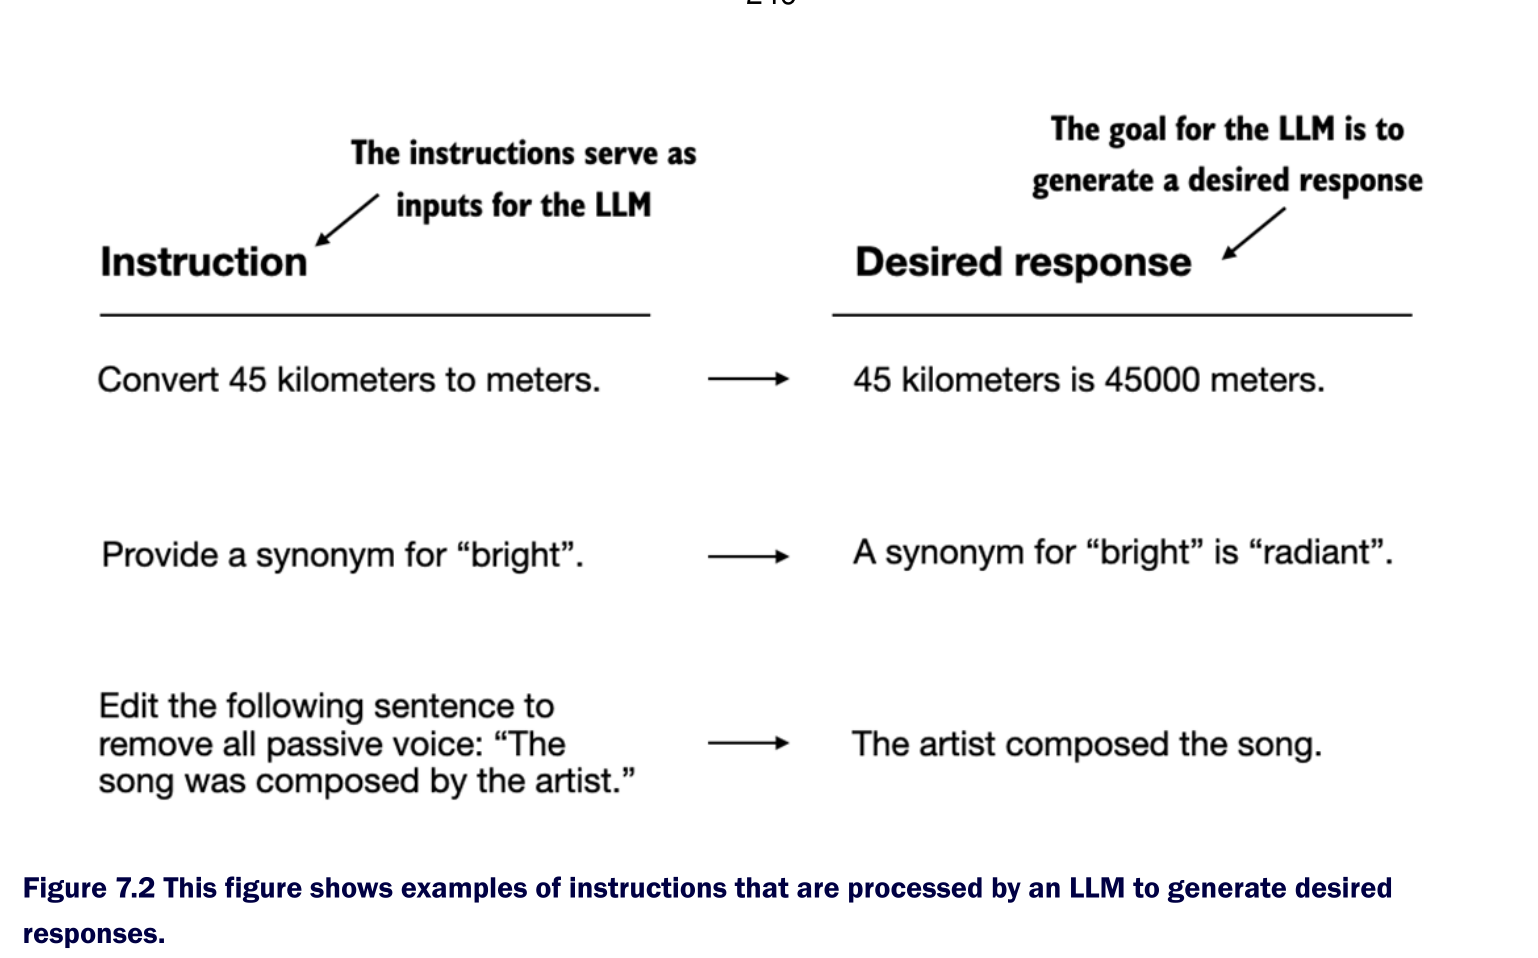

# 7.2 Preparing a dataset for supervised instruction finetuning

The data list , which we loaded from the JSON file contains the 1100 entries of the
instruction dataset. Let's print one of the entries to see how each entry is structured:

In [2]:
import json
import os
import urllib
def download_and_load_file(file_path, url):
    data = []
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
        with open(file_path, "r") as file:
            data = json.load(file)
    return data
if __name__ == "__main__":
    file_path = "instruction-data.json"
    url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"
    data = download_and_load_file(file_path, url)
    print("Number of entries:", len(data))

Number of entries: 1100


Let's see how the input structured


In [3]:
data[50]

{'instruction': 'Identify the correct spelling of the following word.',
 'input': 'Ocassion',
 'output': "The correct spelling is 'Occasion.'"}

There're two ways to format the input data, because If we trained just by give model the raw text, the effience is worse than put it into the pattern.Below there.

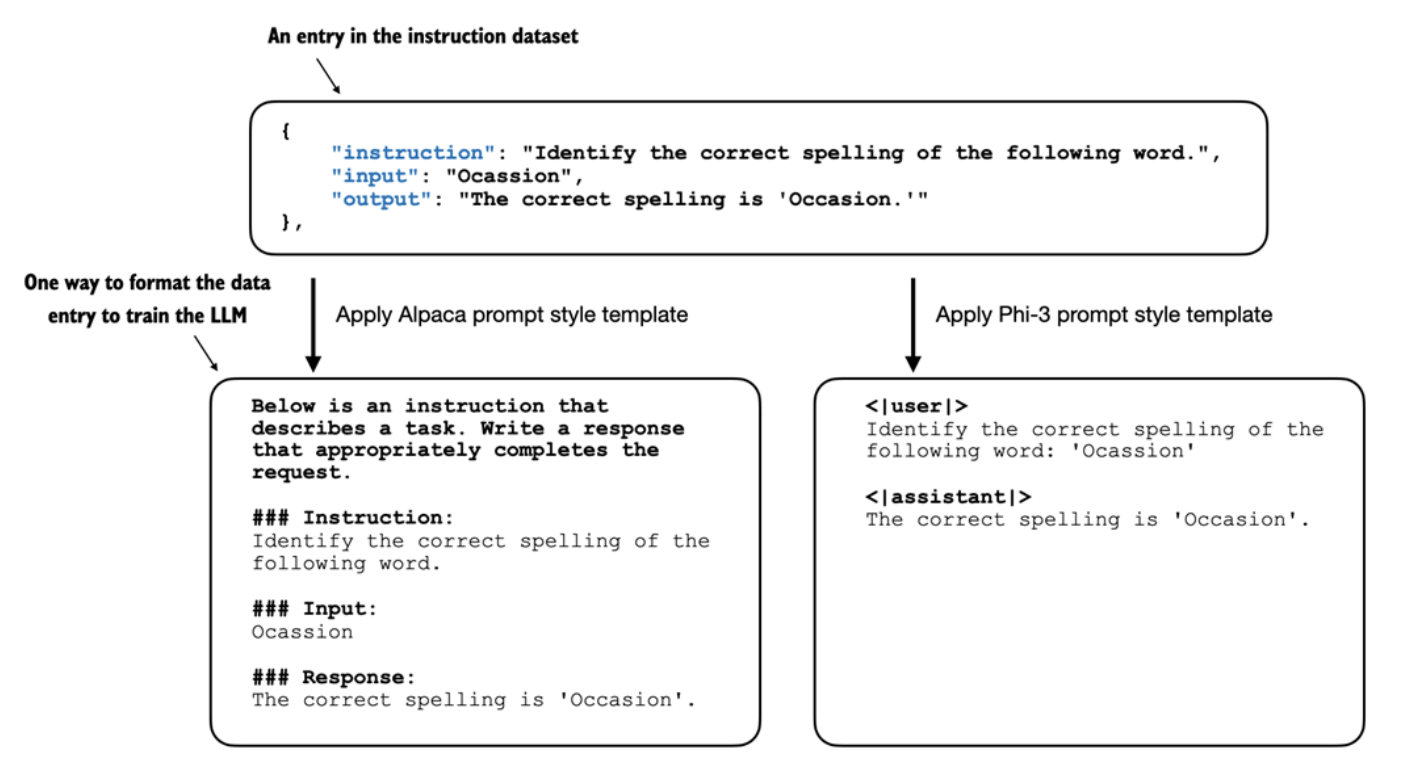

**The rest of this chapter uses the Alpaca prompt style since it is one of the most popular
ones, largely because it helped define the original approach to finetuning.**

# EXERCISE 7.1 CHANGING PROMPT STYLES(NOT DONE)
After finetuning the model with the Alpaca prompt style, try the Phi-3 prompt style
shown in figure 7.4 and observe if it affects the response quality of the model.

In [4]:
def format_entry(entry):
    instruction_text = (
    f"Below is an instruction that describes a task. "
    f"Write a response that appropriately completes the request."
    f"\n\n ### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n ### Input:\n {entry['input']} " if entry['input'] else ""
    return instruction_text + input_text

In [5]:
if __name__ == "__main__":
    model_input = format_entry(data[999])
    desired_response = f"\n\n### Response:\n{data[999]['output']}"
    print(model_input,desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

 ### Instruction:
What is an antonym of 'complicated'? 

### Response:
An antonym of 'complicated' is 'simple'.


let's divide
the dataset into training, validation, and test

In [6]:
def split_data(data,train_ratio,valid_ratio):
    train_portion = int(len(data) * 0.85)# 85% for training
    test_portion = int(len(data) * 0.1)# 10% for testing
    val_portion = len(data) - train_portion - test_portion
    # Remaining 5% for validation
    train_data = data[:train_portion]
    test_data = data[train_portion:train_portion + test_portion]
    val_data = data[train_portion + test_portion:]
    return train_data,test_data,val_data

In [7]:
if __name__ == "__main__":
    train_data,val_data,test_data = split_data(data,0.85,0.1)
    print("Training set length:", len(train_data))
    print("Validation set length:", len(val_data))
    print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 110
Test set length: 55


# 7.3 Organizing data into training batches

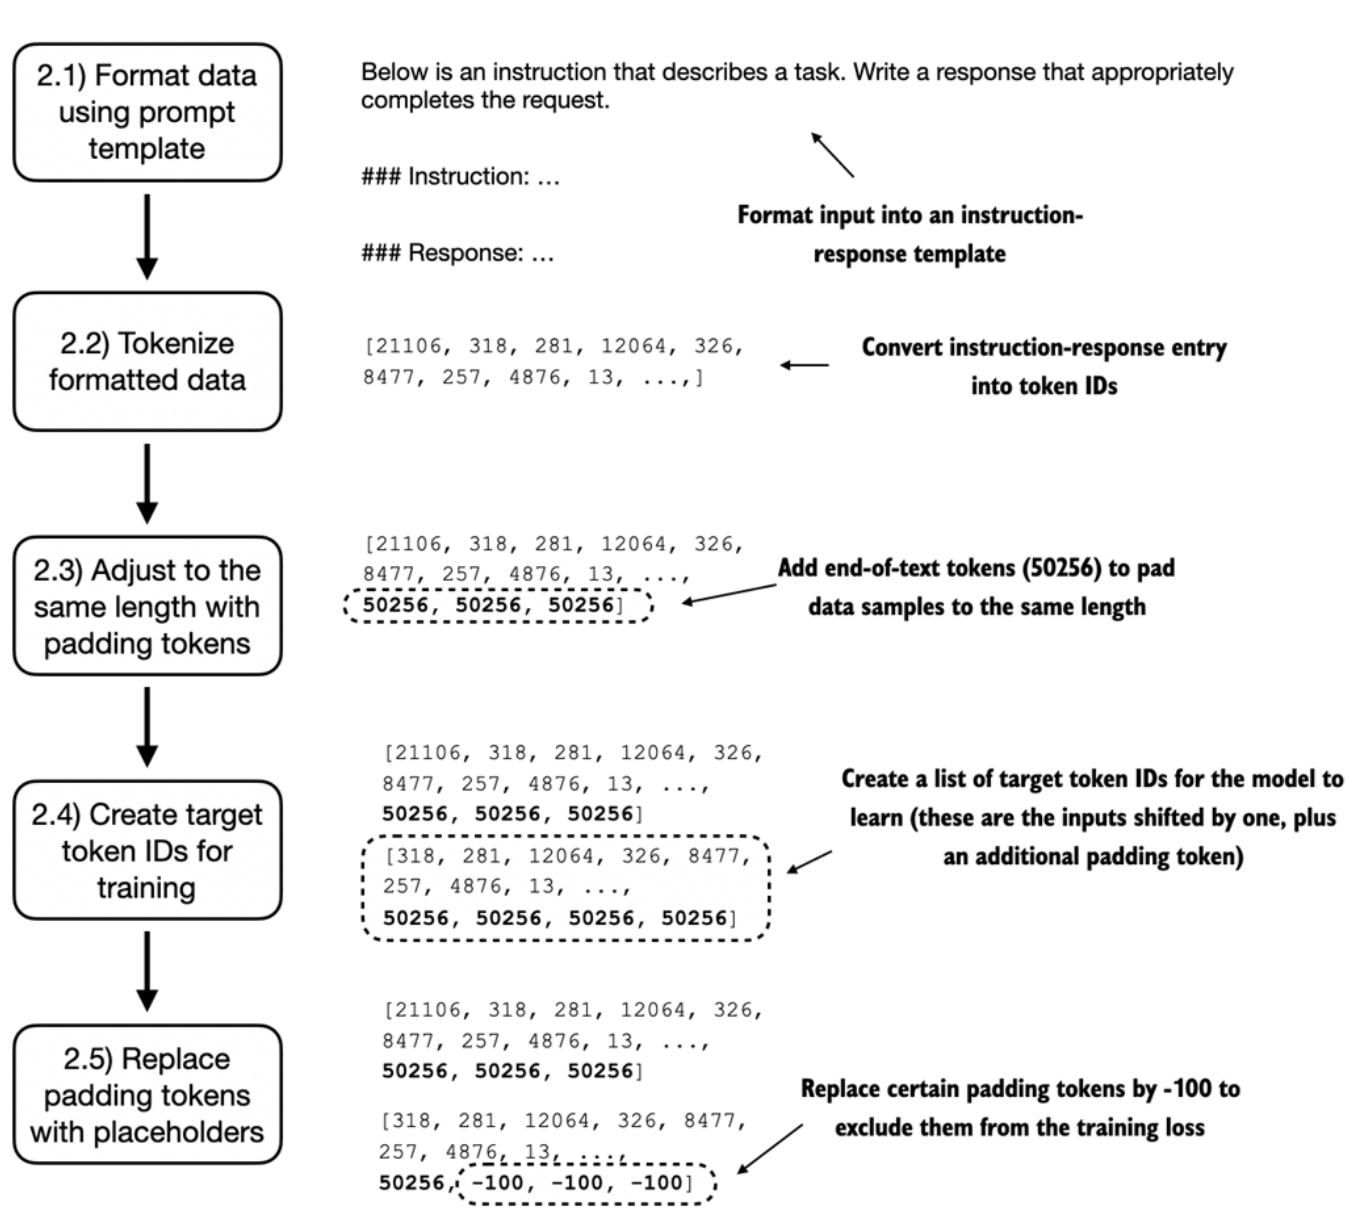

Trong các thư viện như PyTorch (mà bạn đang dùng để cài đặt GPT), hàm tính toán lỗi phổ biến là CrossEntropyLoss. Hàm này có một tham số mặc định là ignore_index = -100.

Khi hàm Loss thấy giá trị mục tiêu (target) là -100, nó sẽ bỏ qua token đó.

Nó không tính điểm, không tính lỗi, và không cập nhật trọng số cho vị trí đó.

## Step 2.1 and 2.2

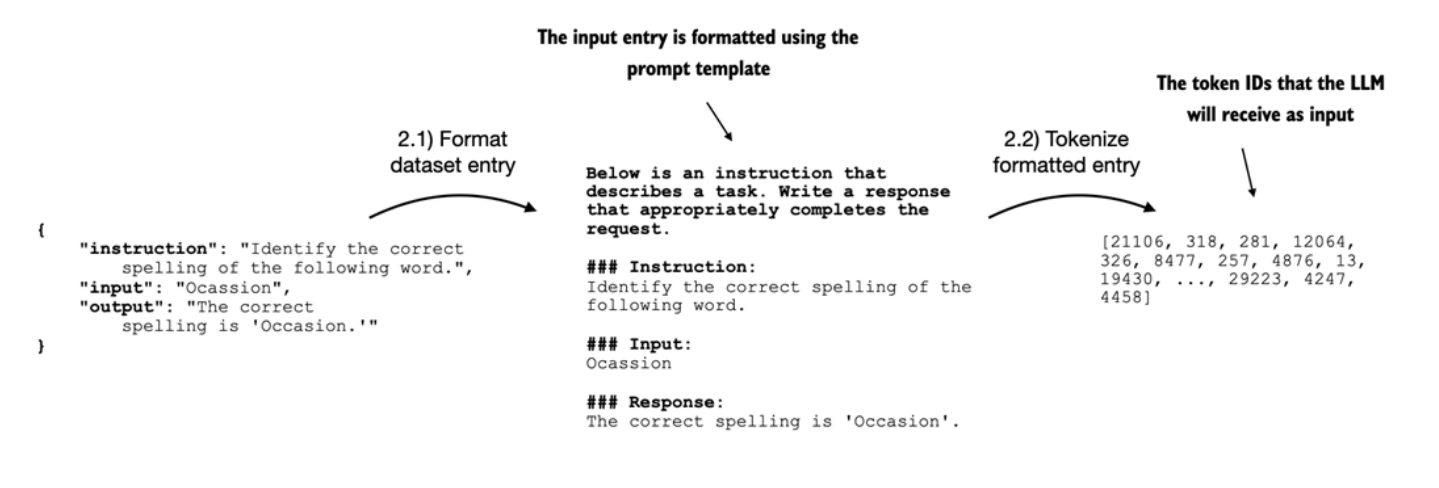

we code an
InstructionDataset class that applies format_input from the previous section and pre-
tokenizes all inputs in the dataset, similar to the SpamDataset in chapter 6.

In [8]:
from torch.utils.data import Dataset
class InstructionDataset(Dataset):
    def __init__(self,data,tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            formated_entry = format_entry(entry)
            response = f"\n\n### Response:\n {entry['output']}"
            full_text = formated_entry + response
            encoded = tokenizer.encode(full_text)
            self.encoded_texts.append(encoded)
    def __getitem__(self,ind):
        return self.encoded_texts[ind]
    def __len__(self):
        return len(self.encoded_texts)

In [9]:
if __name__ == "__main__":
    import tiktoken
    tokenizer = tiktoken.get_encoding("gpt2")
    print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In chapter 6, we padded all examples in a dataset to the same length. Moving on to step
2.3, here, we adopt a more sophisticated approach by developing a custom
collate function that we can pass to the data loader. This custom collate function pads the
training examples in each batch to have the same length, while allowing different batches
to have different lengths, as illustrated in figure 7.8. This approach minimizes unnecessary
padding by only extending sequences to match the longest one in each batch, not the
whole dataset.

In [10]:
def custom_collate_draft_1(batch,pad_token_id=50256,device="cpu"):
    max_length = max(len(item) for item in batch)
    input_list = []
    for item in batch:
        item_cp = item.copy()
        item_cp += [pad_token_id] * (max_length - len(item_cp))
        item_tensor = torch.tensor(item_cp)
        input_list.append(item_tensor)
    inputs_tensor = torch.stack(input_list).to(device)
    return inputs_tensor

In [11]:
if __name__ == "__main__":
    inputs_1 = [1]
    inputs_2 = [5, 6]
    inputs_3 = [7, 8, 9]
    batch = (inputs_1,
             inputs_2,
             inputs_3)
    print(custom_collate_draft_1(batch))

tensor([[    1, 50256, 50256],
        [    5,     6, 50256],
        [    7,     8,     9]])


## Step 2.4

Similar to the process described in chapter 5 for pretraining an LLM, the target token IDs
match the input token IDs but are shifted one position to the right. This setup, as shown in
figure 7.10, allows the LLM to learn how to predict the next token in a sequence.

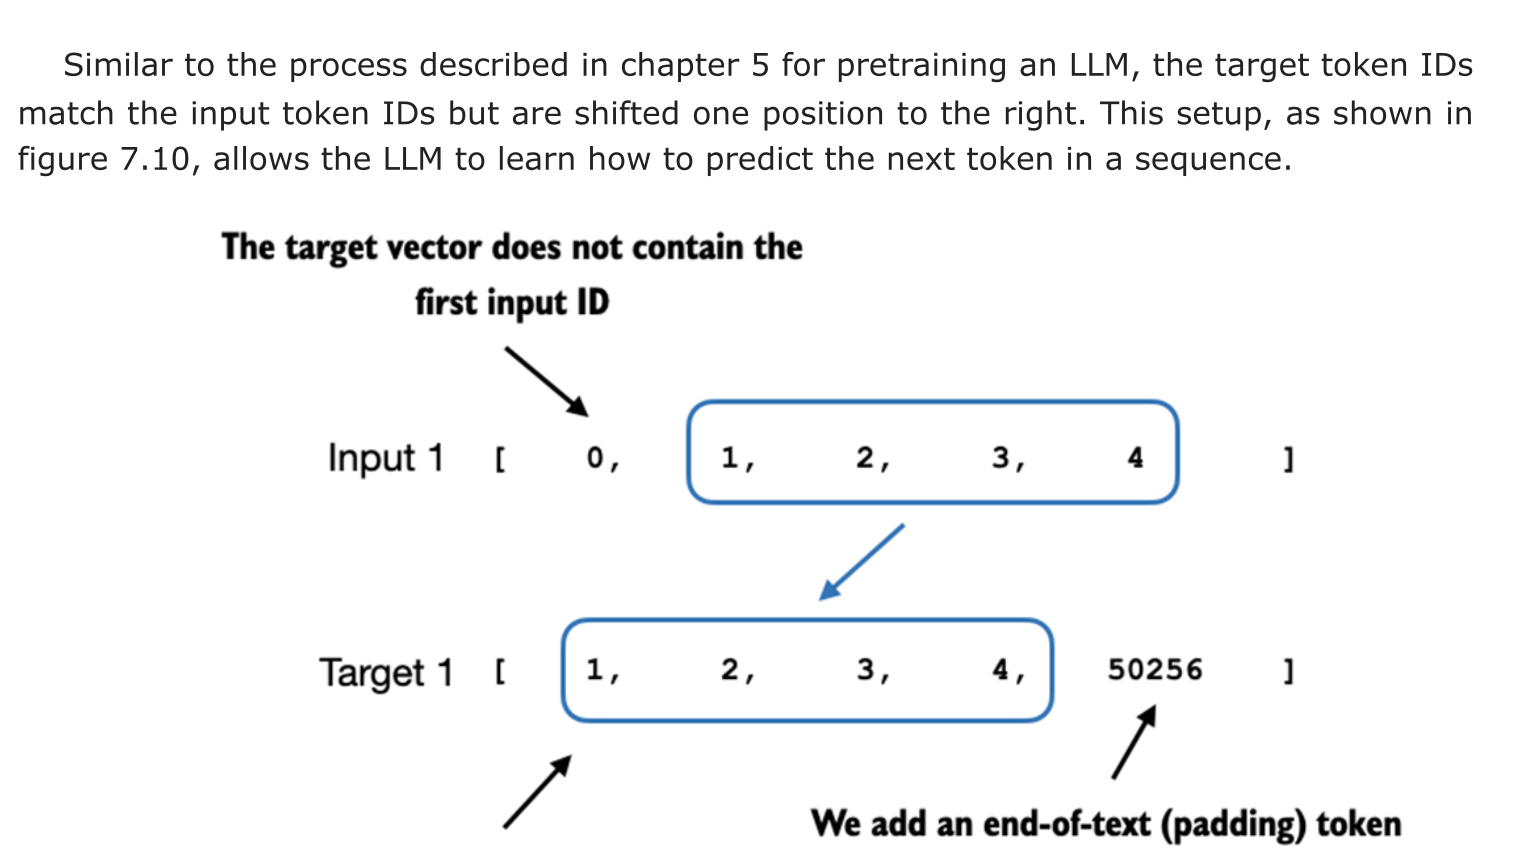

The func below is the updated version.

In [12]:
def custom_collate_draft_2(batch,pad_token_id=50256,device="cpu"):
    max_length = max(len(item) for item in batch)
    input_list = []
    target_list = []
    for item in batch:
        item_cp = item.copy()
        item_cp += [pad_token_id] * (max_length - len(item))
        target = item_cp[1:] + [pad_token_id]
        input_tensor = torch.tensor(item_cp)
        target_tensor = torch.tensor(target)
        input_list.append(input_tensor)
        target_list.append(target_tensor)
    return torch.stack(input_list),torch.stack(target_list)


In [13]:
custom_collate_draft_2(batch)

(tensor([[    1, 50256, 50256],
         [    5,     6, 50256],
         [    7,     8,     9]]),
 tensor([[50256, 50256, 50256],
         [    6, 50256, 50256],
         [    8,     9, 50256]]))

## Step 2.5

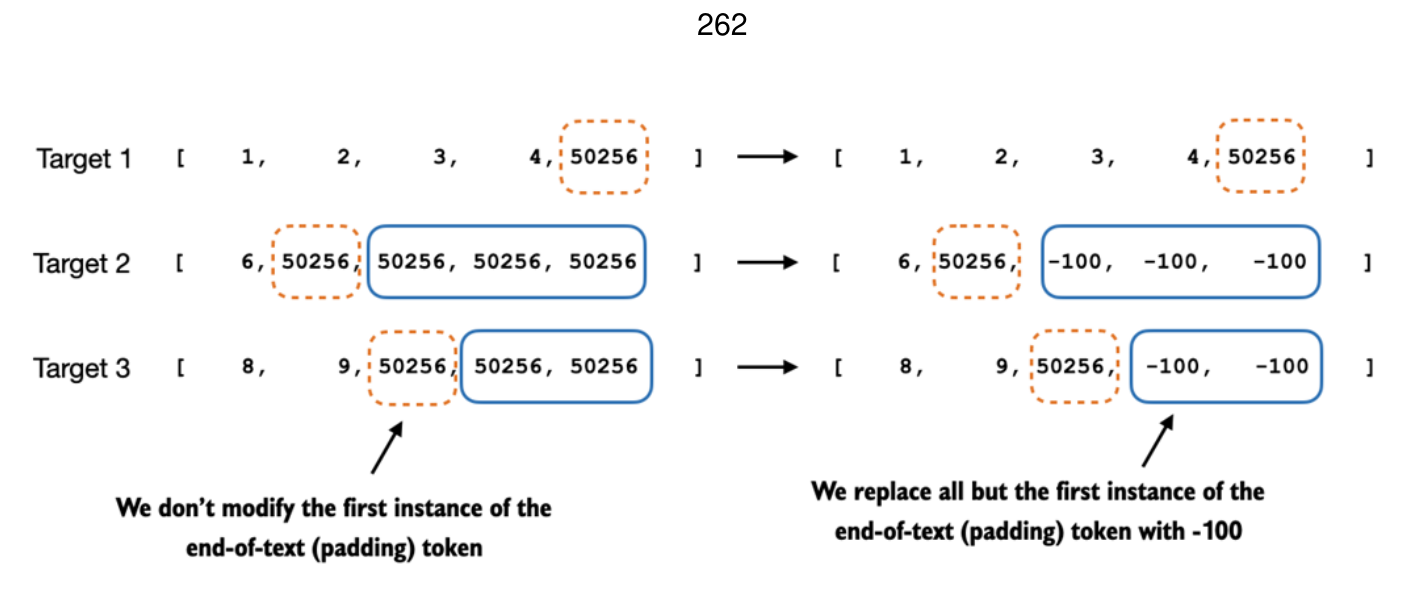

We modify all of padtoken with -100 but keep the first instance

In [14]:
def custom_collate_fn(
batch,
pad_token_id=50256,
ignore_index=-100,
allowed_max_length=None,
device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index # Just adjusted target data
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
        targets = targets[:allowed_max_length]
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst)
    return inputs_tensor,targets_tensor

In [15]:
custom_collate_fn(batch)

(tensor([[    1, 50256, 50256],
         [    5,     6, 50256],
         [    7,     8,     9]]),
 tensor([[50256,  -100,  -100],
         [    6, 50256,  -100],
         [    8,     9, 50256]]))

### The reason why we choose -100 as the ignored_index

In [16]:
logits_1 = torch.tensor(
[[-1.0, 1.0],# predictions for 1st token
[-0.5, 1.5]]# predictions for 2nd token
)
targets_1 = torch.tensor([0, 1]) # Correct token indices to generate
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [17]:
logits_2 = torch.tensor(
[[-1.0, 1.0],
[-0.5, 1.5],
[-0.5, 1.5]]
#A
)
targets_2 = torch.tensor([0, 1, -100])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(1.1269)


As we can see, the predict with target = -100 is ignored

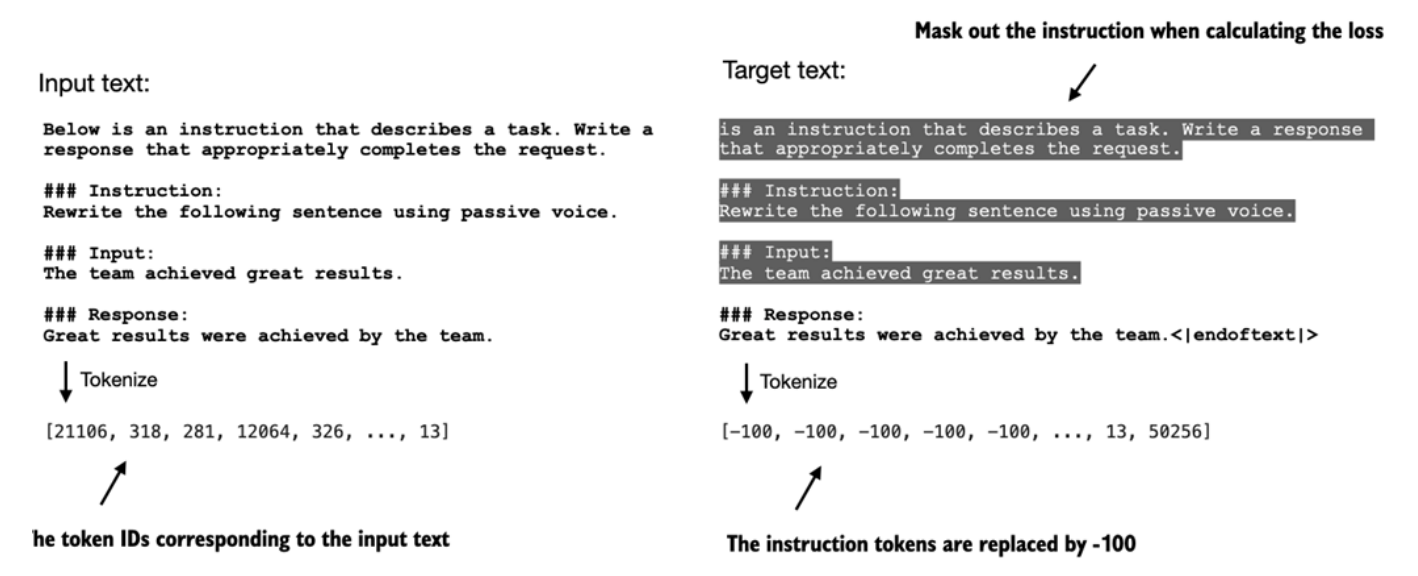

### Important
By masking out the target token IDs that correspond to the instruction, as shown in figure
7.13, the LLM the cross entropy loss is only computed for the generated response target
IDs. By masking out the instruction tokens, the model is trained to focus on generating
accurate responses rather than additionally also memorizing instructions, which can help
with reducing overfitting.

#EXERCISE 7.2 INSTRUCTION AND INPUT MASKING(Not Done)
After completing the chapter and finetuning the model with the InstructionDataset
implemented in this section, replace the instruction and input tokens with the -100
mask to implement the instruction masking method illustrated in Figure 7.13. Then,
evaluate whether this has a positive effect on model performance.

# 7.4 Creating data loaders for an instruction dataset

In [18]:
from torch.utils.data import DataLoader

def dataloader(data,tokenizer,batch_size,num_workers,shuffle):
    dataset = InstructionDataset(data,tokenizer)
    loader = DataLoader(dataset,batch_size,shuffle,collate_fn = custom_collate_fn,num_workers = num_workers)
    return loader


thanks to our custom collate function, the data
loader is able to create batches of different lengths. In the next section, we load a
pretrained LLM that we can then finetune with this data loader.

In [19]:
if __name__ == "__main__":
    batch_size = 8
    train_loader = dataloader(train_data,tokenizer,batch_size, 0,True)
    val_loader = dataloader(val_data,tokenizer,batch_size,0,True)
    test_loader = dataloader(test_data,tokenizer,batch_size,0,True)

    for i,o in train_loader:
        print(i.shape,o.shape)

torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 64]) torch.Size([8, 64])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 60]) torch.Size([8, 60])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 64]) torch.Size([8, 64])
torch.Size([8, 60]) torch.Size([8, 60])
torch.Size([8, 57]) torch.Size([8, 57])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 86]) torch.Size([8, 86])
torch.Size([8, 60]) torch.Size([8, 60])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 59]) torch.Size([8, 59])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 64]) torch.Size([8, 64])
torch.Size([8, 63]) torch.Size([8, 63])


# 7.5 Loading a pretrained LLM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


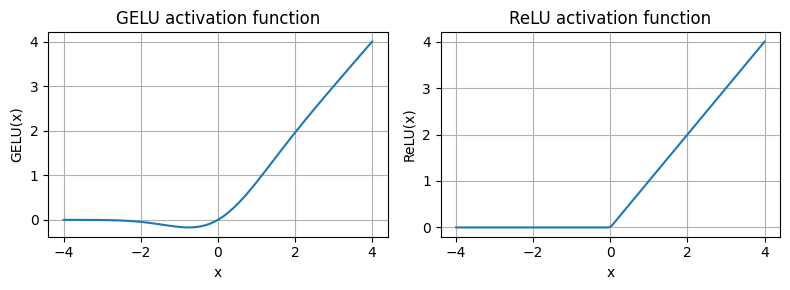

layers.0.0.weight has gradient mean of 0.017917918041348457
layers.1.0.weight has gradient mean of 0.022290976718068123
layers.2.0.weight has gradient mean of 0.011262616142630577
layers.3.0.weight has gradient mean of 0.03297117352485657
layers.4.0.weight has gradient mean of 0.025448836386203766
output.weight has gradient mean of 0.14177103340625763
layers.0.0.weight has gradient mean of 7.291760994121432e-06
layers.1.0.weight has gradient mean of 3.326115620438941e-05
layers.2.0.weight has gradient mean of 7.325314800255e-05
layers.3.0.weight has gradient mean of 0.0006181434146128595
layers.4.0.weight has gradient mean of 0.002277341205626726
output.weight has gradient mean of 0.011895888485014439
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.3556, -0.2533, -0.3395,  ...,  0.0093, -0.6117,  0.0429],
         [-0.1311, 

In [20]:
!pip install importnb
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/')
from importnb import Notebook
with Notebook():
    from Chapter_4 import GPTModel


In [21]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))
import numpy as np
def load_weights_into_gpt(gpt, params):
    gpt.pos_embedded.weight = assign(gpt.pos_embedded.weight, params['wpe']) #A
    gpt.tok_embedded.weight = assign(gpt.tok_embedded.weight, params['wte'])
    for b in range(len(params["blocks"])): #B
        q_w, k_w, v_w = np.split( #C
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)

        gpt.transformer[b].att.W_q.weight = assign(
        gpt.transformer[b].att.W_q.weight, q_w.T)
        gpt.transformer[b].att.W_k.weight = assign(
        gpt.transformer[b].att.W_k.weight, k_w.T)
        gpt.transformer[b].att.W_v.weight = assign(
        gpt.transformer[b].att.W_v.weight, v_w.T)

        q_b, k_b, v_b = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)

        gpt.transformer[b].att.W_q.bias = assign(
        gpt.transformer[b].att.W_q.bias, q_b)
        gpt.transformer[b].att.W_k.bias = assign(
        gpt.transformer[b].att.W_k.bias, k_b)
        gpt.transformer[b].att.W_v.bias = assign(
        gpt.transformer[b].att.W_v.bias, v_b)
        gpt.transformer[b].att.out_proj.weight = assign(
        gpt.transformer[b].att.out_proj.weight,
        params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.transformer[b].att.out_proj.bias = assign(
        gpt.transformer[b].att.out_proj.bias,
        params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.transformer[b].ff.layers[0].weight = assign(
        gpt.transformer[b].ff.layers[0].weight,
        params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.transformer[b].ff.layers[0].bias = assign(
        gpt.transformer[b].ff.layers[0].bias,
        params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.transformer[b].ff.layers[2].weight = assign(
        gpt.transformer[b].ff.layers[2].weight,
        params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.transformer[b].ff.layers[2].bias = assign(
        gpt.transformer[b].ff.layers[2].bias,
        params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.transformer[b].LayerNorm1.gamma = assign(
        gpt.transformer[b].LayerNorm1.gamma,
        params["blocks"][b]["ln_1"]["g"])
        gpt.transformer[b].LayerNorm1.beta = assign(
        gpt.transformer[b].LayerNorm1.beta,
        params["blocks"][b]["ln_1"]["b"])
        gpt.transformer[b].LayerNorm2.gamma = assign(
        gpt.transformer[b].LayerNorm2.gamma,
        params["blocks"][b]["ln_2"]["g"])
        gpt.transformer[b].LayerNorm2.beta = assign(
        gpt.transformer[b].LayerNorm2.beta,
        params["blocks"][b]["ln_2"]["b"])
    gpt.layernorm.scale = assign(gpt.layernorm.gamma, params["g"])
    gpt.layernorm.shift = assign(gpt.layernorm.beta, params["b"])
    gpt.output.weight = assign(gpt.output.weight, params["wte"]) #D


In [22]:
def text_to_token_ids(text,tokenizer):
    encoder = tokenizer.encode(text,allowed_special ={'<|endoftext|>'})
    tensor = torch.tensor(encoder).unsqueeze(0) # Corrected line
    return tensor
def token_to_text(text,tokenizer):
    flat = text.squeeze(0)
    return tokenizer.decode(flat.tolist())
def generate(model, idx, max_new_tokens, context_size, temperature=1.0, top_k=None, eos_idx=None):
    for _ in range(max_new_tokens):
        # 1. Get current input for the model (slice to context_size)
        input_ids = idx[:, -context_size:]

        # 2. Get model predictions (raw logits)
        with torch.no_grad():
            logits = model(input_ids) # Shape: (batch_size, seq_len, vocab_size)

        # We only need the logits for the last token to predict the next
        next_token_logits = logits[:, -1, :] # Shape: (batch_size, vocab_size)

        # 3. Apply Top-K filtering if specified and valid
        if top_k is not None and top_k > 0:
            # Get the top_k values and their indices for each item in the batch
            values, _ = torch.topk(next_token_logits, top_k)
            # Find the smallest value among the top_k for each item
            min_top_k_value = values[:, -1, None] # Add None to enable broadcasting across vocab_size

            # Set logits below the min_top_k_value to -inf
            next_token_logits = torch.where(next_token_logits < min_top_k_value,
                                            torch.tensor(-float("inf"), device=next_token_logits.device),
                                            next_token_logits)

        # 4. Apply Temperature scaling if specified and valid
        # Temperature is applied to the logits before softmax.
        if temperature is not None and temperature > 0.0:
            next_token_logits = next_token_logits / temperature

        # 5. Convert logits to probabilities and sample, or take argmax for deterministic generation
        if temperature is not None and temperature == 0.0:
            # Deterministic generation: pick the token with the highest logit
            idx_next = torch.argmax(next_token_logits, dim=-1, keepdim=True) # keepdim for concatenation
        else:
            # Apply softmax to get probabilities (after top-k filtering and temperature scaling)
            probabilities = torch.softmax(next_token_logits, dim=-1)

            # Sample the next token from the probabilities
            idx_next = torch.multinomial(probabilities, num_samples=1)

        # 6. Check for end-of-sequence token and concatenate the new token
        # Assuming batch size is 1 as per text_to_token_ids output and input idx
        if eos_idx is not None and idx_next.item() == eos_idx:
            break
        else:
            idx = torch.cat((idx, idx_next), dim=-1) # Use torch.cat for consistency with idx_next's shape (batch_size, 1)

    return idx

In [23]:
from gpt_download import download_and_load_gpt2

In [24]:
if __name__ == "__main__":
    BASE_CONFIG = {
    "vocab_size": 50257,# Vocabulary size
    "context_length": 1024,# Context length
    "drop_rate": 0.0,# Dropout rate
    "qkv_bias": True# Query-key-value bias
    }
    model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
    }
    CHOOSE_MODEL = "gpt2-medium (355M)"
    BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
    model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
    settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
    model = GPTModel(BASE_CONFIG)
    load_weights_into_gpt(model, params)
    model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


### Important NOTE
Before diving into finetuning the model in the next section, let's take a moment to assess
the pretrained LLM's performance on one of the validation tasks by comparing its output to
the expected response. This will give us a baseline understanding of how well the model
performs on an instruction-following task right out of the box, prior to finetuning, and will
help us appreciate the impact of finetuning later on. We use the first example from the
validation set for this assessment:

In [25]:
if __name__ == "__main__":
    torch.manual_seed(123)
    input_text = format_entry(val_data[0])
    print(input_text)
    output = generate(model,
                                            text_to_token_ids(input_text,tokenizer),
                                            max_new_tokens = 35,
                                            context_size = BASE_CONFIG['context_length'],
                                            eos_idx = 50256)
    print("OUTPUT: ",token_to_text(output,tokenizer))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

 ### Instruction:
Rewrite the sentence using a simile.

 ### Input:
 The car is very fast. 
OUTPUT:  Below is an instruction that describes a task. Write a response that appropriately completes the request.

 ### Instruction:
Rewrite the sentence using a simile.

 ### Input:
 The car is very fast. , and the-, a, the, a
 the, the- the- the,, the, the the- the, the- the, the, a.


To isolate the model's response text, we need to subtract the length of the input
instruction from the start of the generated_text:

In [26]:
if __name__ == "__main__":
    generated_text = token_to_text(output,tokenizer)
    response_text = generated_text[len(input_text):]
    print(response_text)

, and the-, a, the, a
 the, the- the- the,, the, the the- the, the- the, the, a.


# 7.6 Finetuning the LLM on instruction data

In [27]:
 from Chapter_4 import generate_text_simple
def cal_loss(input_batch,target_batch,model,device):
    input_batch,target_batch = input_batch.to(device),target_batch.to(device)
    pre_batch = model(input_batch)
    #print(pre_batch.shape,target_batch.shape)
    loss = nn.functional.cross_entropy(pre_batch.flatten(0,1),target_batch.flatten())
    return loss
def calc_loss_loader(dataloader,model,device,num_batches = None):
    # Adding num_batches parameters help us to control how many batches have been trained
    if(len(dataloader) == 0):
        return float("nan")
    elif(num_batches == None):
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches,len(dataloader))
    total_loss = 0
    for i,(input,target) in enumerate(dataloader):
        if(i < num_batches):
            loss = cal_loss(input,target,model,device)
            total_loss += loss.item()
        else:
            break

    return total_loss/num_batches
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,eval_freq, eval_iter, start_context, tokenizer):
    train_losses = []
    valid_losses = []
    token_seens = 0
    global_step = -1
    for epoch in range(num_epochs):
        model.train()
        for i,(input_batch,target_batch) in enumerate(train_loader):
            optimizer.zero_grad() # Zero gradients for each batch

            # cal_loss already moves input_batch and target_batch to device
            # and computes model output and loss
            loss = cal_loss(input_batch, target_batch, model, device)

            loss.backward()
            optimizer.step()
            global_step += 1
            token_seens += input_batch.numel()
            if(global_step % eval_freq == 0):
                train_loss, valid_loss = evaluate_model(model,train_loader,val_loader,eval_iter)
                train_losses.append(train_loss)
                valid_losses.append(valid_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {valid_loss:.3f}") # Corrected val_loss to valid_loss
        generate_and_print_sample(model, tokenizer, device, start_context) # Corrected function call
    return train_losses,valid_losses,token_seens
def evaluate_model(model,train_loader,valid_dataloader,eval_iter):
    model.eval()
    train_loss = calc_loss_loader(train_loader,model,device,num_batches= eval_iter)
    val_loss = calc_loss_loader(valid_dataloader,model,device,num_batches=eval_iter)
    model.train()
    return train_loss,val_loss
def generate_and_print_sample(model,tokenizer,device,start_context):
    model.eval()
    context_length = model.pos_embedded.weight.shape[0]
    ids = text_to_token_ids(start_context,tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model,ids,max_new_tokens=50,context_size=context_length)
        decoded_text = token_to_text(token_ids,tokenizer)
        print(decoded_text.replace("\n", " ")) # Compact print format
    model.train()

In [28]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    torch.manual_seed(123)
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader,model,device,num_batches = 5)
        val_loss = calc_loss_loader(train_loader,model,device,num_batches = 5)
        print(train_loss,val_loss)

14.02074089050293 14.709918022155762


### The best part

In [29]:
import torch.optim as optim

In [ ]:
if __name__ == "__main__":
    import time
    start_time = time.time()
    torch.manual_seed(123)
    lr = 0.00005
    optimizer = optim.AdamW(model.parameters(),lr,weight_decay=0.1)
    num_epochs = 2

    train_losses,val_losses,token_seens = train_model_simple(model,train_loader,val_loader,optimizer,device,
                                                             num_epochs,eval_freq = 5,eval_iter = 5,start_context = format_entry(val_data[0]),
                                                             tokenizer = tokenizer)
    end_time = time.time()
    execution_time_minutes = (end_time - start_time) / 60
    print(f"Training completed in {execution_time_minutes:.2f} minutes.")


#EXERCISE 7.3 FINETUNING ON THE ORIGINAL ALPACA DATASET(Not DONE)
The so-called Alpaca dataset by researchers at Stanford is one of the earliest and
most popular openly shared instruction datasets, consisting of 52,002 entries. As an
alternative to the instruction-data.json file we use in this chapter, consider
finetuning an LLM on this dataset. The dataset is available at the following URL:[here](https://raw.​githubusercontent.com/tatsu-​lab/stanford_​alpaca/main/​alpaca_data.​json)

This dataset contains 52,002 entries, which is approximately 50 times more than
those we used in this chapter, and most entries are longer as well. Thus, it's highly
recommended to conduct the training using a GPU to accelerate the finetuning
process. If you encounter out-of-memory errors, consider reducing the batch_size
from 8 to 4, 2, or even 1. Additionally, lowering the allowed_max_length from 1024
to 512 or 256 can further help manage memory issues.

# This part help me to understand what's the things do in train function.

This model didn't calc loss rely on full target sen, It's just predict the next words, for example: input(1,2,3,4) --> target (2,3,4,5)

In [ ]:
if __name__ == "__main__":
    inputs,outputs = next(iter(train_loader))
    print(outputs.shape)
    inputs.shape
    optimizer.zero_grad() # Zero gradients for each batch
    loss = cal_loss(inputs,outputs,model,device)
    print(loss)
    loss.backward()
    optimizer.step()
    inputs.shape


# 7.7 Extracting and saving responses

In [ ]:
torch.manual_seed(123)
def model_response_testing(test_data,model,idx):
    for entry in test_data[:idx]:
        input_text = format_entry(entry)
        token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_idx=50256
        )
        generated_text = token_to_text(token_ids, tokenizer)
        response_text = generated_text[len(input_text):].replace("### Response:",
        "").strip()
        print(input_text)
        print(f"\nCorrect response:\n>> {entry['output']}")
        print(f"\nModel response:\n>> {response_text.strip()}")
        print("-------------------------------------")


In [ ]:
if __name__ == "__main__":
    model_response_testing(test_data,model,3)

### Model evaluation:

Most importantly, we can see that model evaluation is not as straightforward as in the
previous chapter, where we simply calculated the percentage of correct spam/non-spam
class labels to obtain the classification accuracy. In practice, instruction-finetuned LLMs
such as chatbots are evaluated via multiple approaches:
1.
Short-answer and multiple choice benchmarks such as MMLU ("Measuring
Massive Multitask Language Understanding,"[ here](https://arxiv.​org/abs/2009.​03300), which test the general knowledge of a model.
2.Human preference comparison to other LLMs, such as LMSYS chatbot
arena ([here](https://arena.​lmsys.org)).
3.Automated conversational benchmarks, where another LLM like GPT-4 is
used to evaluate the responses, such as AlpacaEval ([here](https://tatsu-​lab.github.​io/alpaca_​eval)).

To prepare the responses for this evaluation process, we append the generated model
responses to the test_set dictionary and save the updated data as an "instruction-
data-with-response.json" file for record keeping. Additionally, by saving this file, we can
easily load and analyze the responses in separate Python sessions later on if needed.
The following code uses the generate method in the same manner as before; however,
we now iterate over the entire test_set. Also, instead of printing the model responses, we
add them to the test_set dictionary:

# 7.8 Evaluating the finetuned LLM

In this section, as indicated in the chapter overview in figure 7.19, we implement a method
to automate the response evaluation of the finetuned LLM using another, larger LLM.

We can use LLAMA for Evaluation with the code below.

The code must be run on local laptop so I didn't write my code here. This section can be read from page 290 in LLM books.

**Thanks Sebastian Raschka ARGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG**